# Forecasting with foundational models

Foundation Models (FMs) have recently introduced a major paradigm shift in the field of time series forecasting. Driven by the same architectural breakthroughs that power Large Language Models (LLMs), these models offer powerful generalization capabilities out-of-the-box.

This guide introduces what Foundation Models are, how they differ from traditional machine learning approaches, and how **skforecast** seamlessly integrates them into your forecasting pipelines.

## Introduction to Foundation Models

In the context of time series, a Foundation Model is a large-scale neural network (typically based on Transformer architectures) that has been pre-trained on massive and highly diverse datasets spanning multiple domains (e.g., finance, weather, web traffic, and retail).

Models such as **AWS Chronos**, **Salesforce MOIRAI** and **Lag-Llama** operate on a principle similar to language models: they treat time series values as a sequence of tokens. Because they have already "seen" millions of time series patterns during their pre-training phase, they can identify trends, seasonality, and complex dynamics in new, unseen data without requiring any domain-specific training.

## Foundation Models vs. Machine Learning Models

Foundation models and traditional machine learning models approach forecasting in fundamentally different ways. Understanding these distinctions is crucial for knowing when and how to deploy each method.

**Zero-Shot Prediction**

Machine learning models require a training phase. You must fit the model on your historical target data (and exogenous variables) so the algorithm can learn the optimal weights and parameters for your specific time series. Foundation models are capable of zero-shot prediction. Because the model's parameters are already frozen from its massive pre-training phase, it can generate forecasts on your data immediately, without explicitly "learning" from your specific dataset first.

**The Role of the fit Method**

Calling .fit(y) in machine learning models triggers the optimization algorithm to minimize an error metric, updating the model's internal parameters. In foundation models, calling .fit(y) does not alter the model's neural network weights. Instead, the fit method acts as a standardizer. It is used merely to store necessary metadata (such as the last observed window of data, frequency, and scaling factors) so that the .predict() method has the exact context it needs to generate future values.

**Context Window vs. Engineered Lags**

Machine learning models rely on explicitly engineered features. In skforecast, you define lags or window_features to create a tabular dataset where past values are used as columns to predict the target. Foundation models rely on a context window. You pass a raw, sequential chunk of recent historical data (e.g., the last 512 observations) directly into the model at inference time. The attention mechanism inside the model automatically decides which past data points are most relevant.

## FoundationalModel

The open-source ecosystem for Foundation Models is currently highly fragmented. To solve this, skforecast introduces the `FoundationalModel` class. This wrapper acts as a translation layer, unifying disparate FMs behind the familiar scikit-learn API. Regardless of the underlying model's native code, `FoundationalModel` ensures you can always interact with it using standard methods: `.fit()`, `.predict()`, `.get_params()` and `.set_params()`.

```text
                          ┌─────────────────────────┐
                          │    FoundationalModel    │
                          │  (skforecast Wrapper)   │
                          └────┬───────────────┬────┘
                               │               │
                      ┌────────┴───────┐ ┌─────┴──────────┐
                      │    .fit(y)     │ │  .predict(h)   │
                      │(Store Context) │ │(Zero-Shot Run) │
                      └────────┬───────┘ └─────┬──────────┘
                               │               │
     ┌─────────────────────────┴───────────────┴─────────────────────────┐
     │                     Internal Model Adapters                       │
     │  ┌────────────┐   ┌────────────┐   ┌────────────┐  ┌────────────┐ │
     │  │ AWS Chronos│   │   MOIRAI   │   │  TimesFM   │  │     ...    │ │
     │  └────────────┘   └────────────┘   └────────────┘  └────────────┘ │
     └───────────────────────────────────────────────────────────────────┘
```

## ForecasterFoundational

The true power of integrating Foundation Models into **skforecast** lies in the `ForecasterFoundational` class. By wrapping a `FoundationalModel`, you immediately unlock the entire suite of skforecast validation and evaluation tools, treating the massive neural network exactly like a simple Ridge Regressor. Because the API is identical, you can easily run a bake-off between a zero-shot AWS Chronos model and a highly-tuned XGBoost model (ForecasterAutoreg) on the same dataset using the exact same backtesting code.

```text
                          ┌─────────────────────────┐
                          │  skforecast ecosystem   │
                          └────────────┬────────────┘
                                       │
                          ┌────────────┴────────────┐
                          │ ForecasterFoundational  │
                          │      (forecasting)      │
                          └────────────┬────────────┘
                                       │
                          ┌────────────┴────────────┐
                          │    FoundationalModel    │
                          │  (skforecast Wrapper)   │
                          └────┬───────────────┬────┘
                               │               │
                      ┌────────┴───────┐ ┌─────┴──────────┐
                      │    .fit(y)     │ │  .predict(h)   │
                      │(Store Context) │ │(Zero-Shot Run) │
                      └────────┬───────┘ └─────┬──────────┘
                               │               │
     ┌─────────────────────────┴───────────────┴─────────────────────────┐
     │                     Internal Model Adapters                       │
     │  ┌────────────┐   ┌────────────┐   ┌────────────┐  ┌────────────┐ │
     │  │ AWS Chronos│   │   MOIRAI   │   │  TimesFM   │  │    ...     │ │
     │  └────────────┘   └────────────┘   └────────────┘  └────────────┘ │
     └───────────────────────────────────────────────────────────────────┘
     ```

## Input Data Formats

The following sections detail the supported data formats for target series, exogenous variables, and index types within the ForecasterFoundational framework.


### Target Series (`series`)

The `series` parameter in the `.fit()` method supports both single-series and multi-series (global model) configurations.

| Mode | Allowed Data Type | Description |
| :--- | :--- | :--- |
| **Single-Series** | pd.Series | A single time series with a named index. |
| **Multi-Series (Wide)** | pd.DataFrame | A DataFrame where **each column** represents a separate time series. |
| **Multi-Series (Long)** | pd.DataFrame | A DataFrame with a **MultiIndex** (Level 0: Series IDs, Level 1: DatetimeIndex). |
| **Multi-Series (Dict)** | dict[str, pd.Series] | A dictionary where keys are series identifiers and values are pandas Series. |

<br>

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

While Long-format DataFrames are supported, they are converted to dictionaries internally. For optimal performance, pass a <code>dict[str, pd.Series]</code> directly.

</div>


### Exogenous Variables (`exog`)

Exogenous variables (covariates) must align with the target series. These are mapped to `past_covariates` or `future_covariates` during the prediction phase.

**Single-Series Mode**

+ `pd.Series` or `pd.DataFrame`: Must be aligned to the target series index and contain the same number of samples.

**Multi-Series Mode**

+ Dictionary: A `dict[str, pd.Series | pd.DataFrame | None]` containing one entry per series.

+ Broadcast: A single `pd.Series` or `pd.DataFrame` that is automatically applied to all series in the model.

+ Long Format: A `pd.DataFrame` using a **MultiIndex** (Level 0: Series IDs, Level 1: `DatetimeIndex`).

## Libraries and data

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent.parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

/home/ubuntu/varios/skforecast
0.21.0


In [2]:
# Libraries
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from skforecast.datasets import fetch_dataset
from skforecast.foundational import ForecasterFoundational, FoundationalModel
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_foundational
)
from skforecast.plot import set_dark_theme

/home/ubuntu/anaconda3/envs/skforecast_22_py13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Data download
# ==============================================================================
data = fetch_dataset(name='vic_electricity')

# Aggregating in 1H intervals
# ==============================================================================
# The Date column is eliminated so that it does not generate an error when aggregating.
data = data.drop(columns="Date")
data = (
    data
    .resample(rule="h", closed="left", label="right")
    .agg({
        "Demand": "mean",
        "Temperature": "mean",
        "Holiday": "mean",
    })
)
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Holiday
Time,,,
2011-12-31 14:00:00,4323.095350,21.225,1.0
2011-12-31 15:00:00,3963.264688,20.625,1.0
2011-12-31 16:00:00,3950.913495,20.325,1.0


In [4]:
# Split data into train-test
# ==============================================================================
data = data.loc['2012-01-01 00:00:00':'2014-12-30 23:00:00', :].copy()
end_train = '2014-11-30 23:59:00'
data_train = data.loc[: end_train, :].copy()
data_test  = data.loc[end_train:, :].copy()

print(f"Train dates: {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")


Train dates: 2012-01-01 00:00:00 --- 2014-11-30 23:00:00  (n=25560)
Test dates : 2014-12-01 00:00:00 --- 2014-12-30 23:00:00  (n=720)


## Forecasting with ForecasterFoundational

A `ForecasterFoundational` is created using the aws **chronos-2-small** model.

### Creating forecaster

In [5]:
# Create ForecasterFoundational
# ==============================================================================
estimator = FoundationalModel(model="autogluon/chronos-2-small")
forecaster = ForecasterFoundational(estimator = estimator)


In [6]:
# Train ForecasterFoundational
# ==============================================================================
forecaster.fit(series=data_train["Demand"], exog=data_train[["Temperature", "Holiday"]])
forecaster

====================== 
ForecasterFoundational 
====================== 
Model: autogluon/chronos-2-small 
Context length: 2048 
Cross learning: False 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature, Holiday 
Training range: [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-03-25 12:40:24 
Last fit date: 2026-03-25 12:40:24 
Skforecast version: 0.21.0 
Python version: 3.13.12 
Forecaster id: None

### Prediction

Three methods can be used to predict the next $n$ steps ahead: `predict()`, `predict_interval()`, and `predict_quantiles()`. All of these methods allow for passing `last_window` and `last_window_exog` to override the historical context used by the underlying model to generate predictions.

In [ ]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(steps=steps)
predictions.head(3)

2014-12-01 00:00:00    5751.756836
2014-12-01 01:00:00    5713.385742
2014-12-01 02:00:00    5661.635742
Freq: h, Name: pred, dtype: float32

In [8]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    interval = [10, 90],  # 80% prediction interval
)
predictions_intervals.head(3)

,pred,lower_bound,upper_bound
2014-12-01 00:00:00,5751.756836,5610.326172,6000.323730
2014-12-01 01:00:00,5713.385742,5486.602051,6099.981445
2014-12-01 02:00:00,5661.635742,5374.642578,6124.604004


### Backtesting

In [15]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = len(data.loc[:end_train]),
        refit              = False
)

metrics_levels, backtest_predictions = backtesting_foundational(
    forecaster = forecaster,
    series     = data['Demand'],
    exog       = data[["Temperature", "Holiday"]],
    cv         = cv,
    metric     = 'mean_absolute_error',
)

print("Backtest metrics")
display(metrics_levels)
print("")
print("Backtest predictions")
backtest_predictions.head(4)


  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:15<00:00,  2.00it/s]

Backtest metrics


,mean_absolute_error
0,157.032133



Backtest predictions


,fold,pred
Time,,
2014-12-01 00:00:00,0,5501.366699
2014-12-01 01:00:00,0,5450.032227
2014-12-01 02:00:00,0,5375.812500
2014-12-01 03:00:00,0,5315.423828


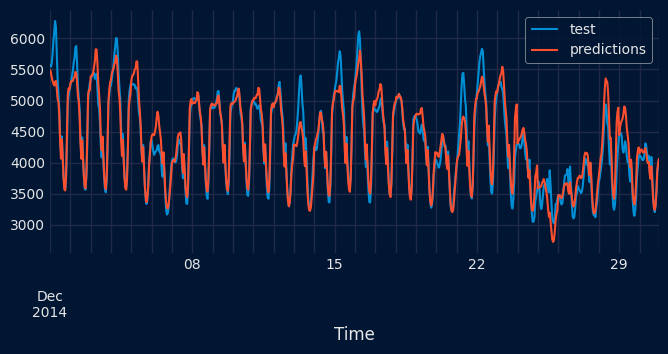

In [12]:
# Plot predictions
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
data_test['Demand'].plot(ax=ax, label='test')
backtest_predictions['pred'].plot(ax=ax, label='predictions')
ax.legend();

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

These results are for illustrative purposes. Since this is a widely available public dataset, it is highly probable that the model was exposed to these specific data points during its pre-training phase. As a result, the predictions may be more optimistic than what would be achieved in a real-world production environment.

</div>

### Forecasting multiple series (global model)

The class <code>[ForecasterFoundational](../api/forecasterfoundational.html)</code> allows to model and forecast multiple scenarios with a single model.

In [34]:
# Data
# ==============================================================================
data = fetch_dataset(name="items_sales")
display(data.head(3))

╭─────────────────────── items_sales ───────────────────────╮
│ Description:                                              │
│ Simulated time series for the sales of 3 different items. │
│                                                           │
│ Source:                                                   │
│ Simulated data.                                           │
│                                                           │
│ URL:                                                      │
│ https://raw.githubusercontent.com/skforecast/skforecast-  │
│ datasets/main/data/simulated_items_sales.csv              │
│                                                           │
│ Shape: 1097 rows x 3 columns                              │
╰───────────────────────────────────────────────────────────╯

,item_1,item_2,item_3
date,,,
2012-01-01,8.253175,21.047727,19.429739
2012-01-02,22.777826,26.578125,28.009863
2012-01-03,27.549099,31.751042,32.078922


In [26]:
# Split data into train-test
# ==============================================================================
end_train = '2014-07-15 23:59:00'
data_train = data.loc[:end_train, :]
data_test  = data.loc[end_train:, :]

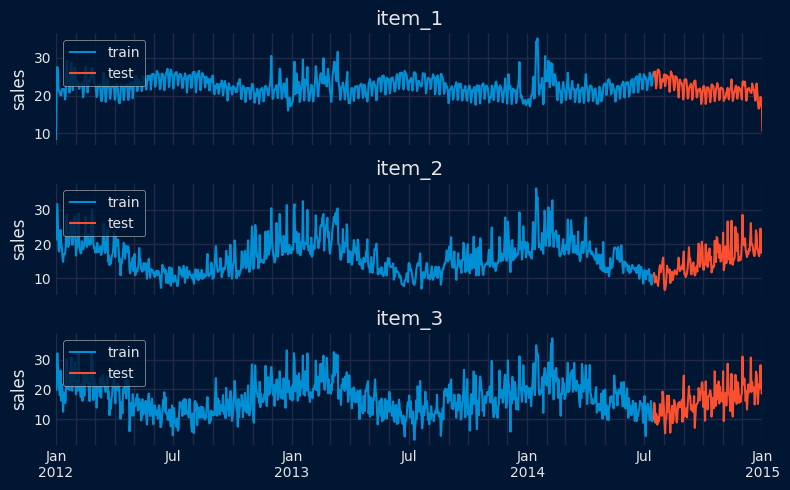

In [30]:
# Plot time series
# ==============================================================================
set_dark_theme()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 5), sharex=True)

for i, col in enumerate(data.columns):
    data_train[col].plot(ax=axes[i], label='train')
    data_test[col].plot(ax=axes[i], label='test')
    axes[i].set_title(col)
    axes[i].set_ylabel('sales')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper left')

fig.tight_layout()
plt.show();

In [31]:
# Create and train ForecasterFoundational
# ==============================================================================
estimator = FoundationalModel(model="autogluon/chronos-2-small")
forecaster = ForecasterFoundational(estimator = estimator)
forecaster.fit(series=data_train)
forecaster

====================== 
ForecasterFoundational 
====================== 
Model: autogluon/chronos-2-small 
Context length: 2048 
Cross learning: False 
Series names: ['item_1', 'item_2', 'item_3'] 
Exogenous included: False 
Exogenous names: None 
Training range: {'item_1': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')], 'item_2': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')], 'item_3': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-07-15 00:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Creation date: 2026-03-25 14:22:12 
Last fit date: 2026-03-25 14:22:12 
Skforecast version: 0.21.0 
Python version: 3.13.12 
Forecaster id: None

In [ ]:
# Predictions and prediction intervals
# ==============================================================================
steps = 24

# Predictions for item_1 and item_2
predictions_item_1 = forecaster.predict(steps=steps, levels=['item_1', 'item_2'])
display(predictions_item_1.head())
print("")

# Interval predictions for item_1 and item_2
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    levels   = ['item_1', 'item_2'],
    interval = [10, 90],  # 80% prediction interval
)
predictions_intervals.head()

,level,pred
2014-07-16,item_1,25.393276
2014-07-16,item_2,10.694120
2014-07-17,item_1,25.141916
2014-07-17,item_2,10.868246
2014-07-18,item_1,25.119213


,level,pred,lower_bound,upper_bound
2014-07-16,item_1,25.393276,24.595732,26.200487
2014-07-16,item_2,10.694120,8.742791,13.271327
2014-07-17,item_1,25.141916,24.192814,26.036993
2014-07-17,item_2,10.868246,8.804617,13.735439
2014-07-18,item_1,25.119213,24.065231,26.078648
2014-07-18,item_2,10.891085,8.761942,13.879732
2014-07-19,item_1,23.781929,22.731443,24.800146
2014-07-19,item_2,10.985981,8.792200,13.833502
2014-07-20,item_1,21.413382,20.560738,22.379049
2014-07-20,item_2,11.076559,8.831981,14.022476
